Mean Squared Error: 46.50786410059162
R-squared Score: 0.9913910898580541


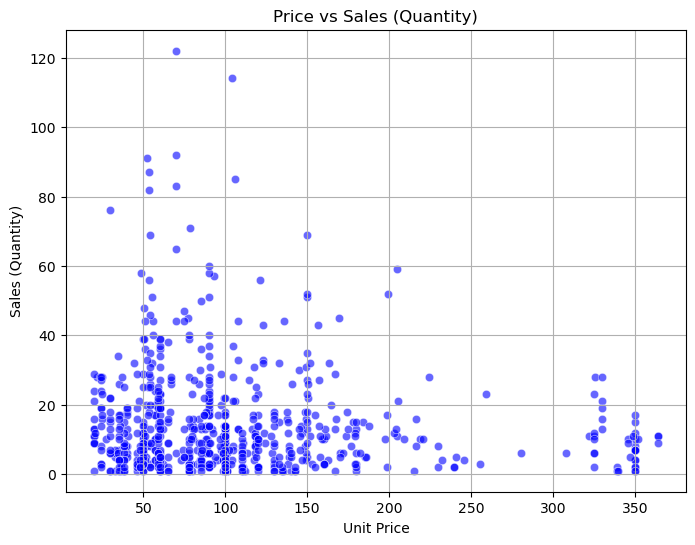

In [35]:
# This is to Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# This is to load the dataset
file_path = r"C:\Users\usmank\OneDrive - Access-ARM Pensions\Documents\Nexford Assignments\Business Analytics Capstone\Final Project\Business analytics ready dataset (Final Project).csv"
data = pd.read_csv(file_path)

# This is to select features and target variable
features = ['qty', 'freight_price', 'comp_1', 'ps1', 'fp1', 
            'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']
target = 'unit_price'

X = data[features]
y = data[target]

# This is to handle missing values (if any)
X = X.fillna(X.mean())

# This is to split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# This is to standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# This is to train the XGBoost Regressor
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# this is to make predictions
y_pred = xgb_model.predict(X_test_scaled)

# This is the model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)


# This is Data Visualization: Price vs Sales (Qty)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['unit_price'], y=data['qty'], alpha=0.6, color='blue')
plt.title('Price vs Sales (Quantity)')
plt.xlabel('Unit Price')
plt.ylabel('Sales (Quantity)')
plt.grid(True)
plt.show()

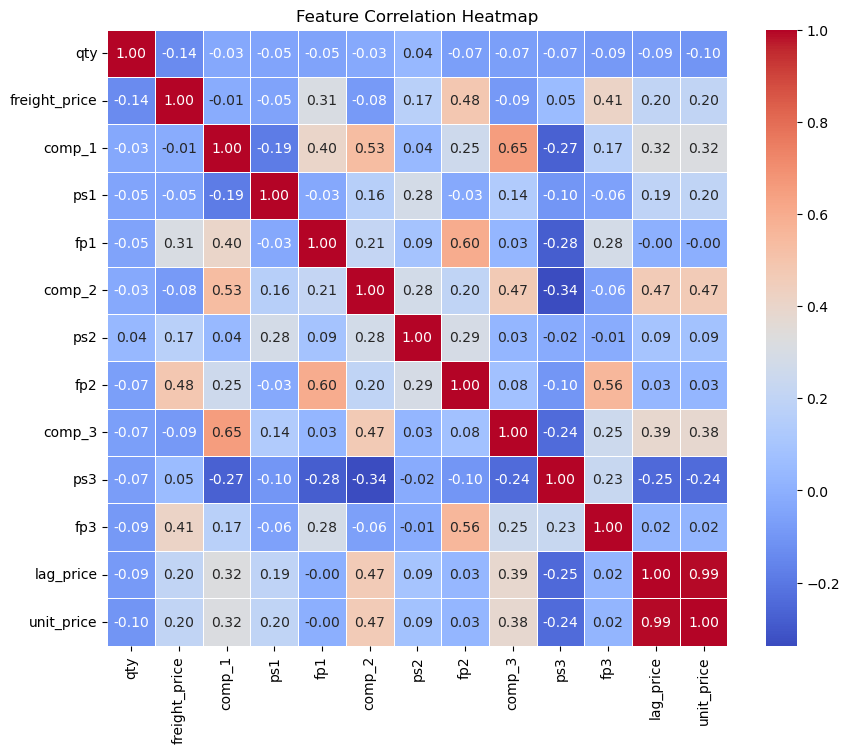

In [31]:
# This is Data Visualization: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data[features + [target]].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

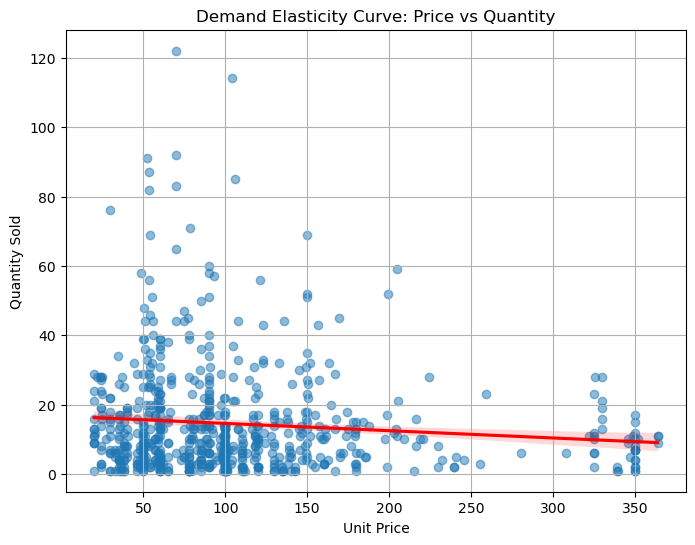

In [33]:
# This is Data Visualization: Demand Elasticity Curve
plt.figure(figsize=(8, 6))
sns.regplot(x=data['unit_price'], y=data['qty'], scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Demand Elasticity Curve: Price vs Quantity')
plt.xlabel('Unit Price')
plt.ylabel('Quantity Sold')
plt.grid(True)
plt.show()

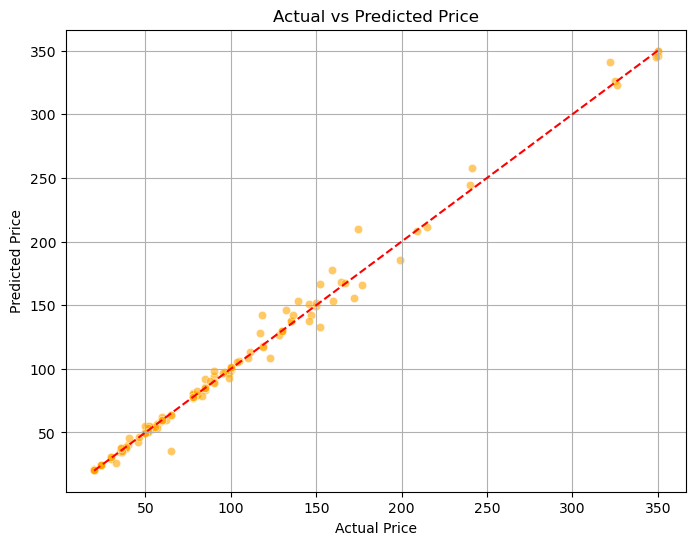

In [37]:
# This is Data Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='orange', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()